# Retail Sales Analysis & Customer Segmentation

**Author:** Data Analyst Portfolio Project
**Tools:** Python, Pandas, Matplotlib, Seaborn, Scikit-learn

## 1. Project Introduction

### Business Context
A mid-sized global e-commerce retailer wants to better understand its sales
performance and its customers so that marketing and inventory decisions can
be made with data instead of guesswork. Leadership has asked for an analysis
that answers three questions:

1. **How is the business performing over time**, and which products/categories/regions
   drive revenue?
2. **Who are our customers**, and can we group them into meaningful segments
   (e.g. loyal high-value customers vs. one-time bargain shoppers)?
3. **What should the business do next** based on these findings?

### Dataset
This project uses a transaction-level sales dataset (`retail_sales_data.csv`)
structured the same way as the well-known **UCI/Kaggle "Online Retail"**
dataset: one row per line-item in an invoice, with customer, product, and
pricing information. (A realistic synthetic dataset with ~5,400 transactions,
350 customers, 7 countries, and 7 product categories was generated for this
project so that it is fully self-contained and reproducible — the same code
runs unchanged against the real UCI Online Retail dataset.)

**Columns:**
| Column | Description |
|---|---|
| `InvoiceNo` | Unique order/invoice identifier |
| `InvoiceDate` | Date the order was placed |
| `CustomerID` | Unique customer identifier |
| `Country` | Customer's country |
| `ProductCategory` | Product category |
| `ProductName` | Product name |
| `Quantity` | Units purchased (negative = return) |
| `UnitPrice` | Price per unit (USD) |
| `TotalPrice` | `Quantity x UnitPrice` |

### Project Roadmap
1. Project Introduction *(this section)*
2. Data Exploration
3. Data Cleaning
4. Exploratory Analysis & Visualization (sales trends, top products, demographics)
5. Customer Segmentation (RFM + K-Means clustering)
6. Conclusion & Business Recommendations


In [1]:
# Core libraries for data manipulation, visualization, and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Consistent, presentation-ready plot styling for the whole notebook
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
COLOR = "#2E5EAA"
PALETTE = ["#2E5EAA", "#E8823C", "#3AA655", "#C94F4F", "#8D6BAF", "#4FA9A6", "#B08A3E"]

pd.set_option("display.max_columns", None)


## 2. Data Exploration

Before doing any analysis, we load the raw data and get a feel for its
shape, types, and quality issues.

In [2]:
df = pd.read_csv("retail_sales_data.csv", parse_dates=["InvoiceDate"])
print("Shape:", df.shape)
df.head()


Shape: (5424, 9)


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5424 entries, 0 to 5423
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   InvoiceNo        5424 non-null   str           
 1   InvoiceDate      5424 non-null   datetime64[us]
 2   CustomerID       5399 non-null   float64       
 3   Country          5424 non-null   str           
 4   ProductCategory  5424 non-null   str           
 5   ProductName      5424 non-null   str           
 6   Quantity         5424 non-null   int64         
 7   UnitPrice        5424 non-null   float64       
 8   TotalPrice       5424 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 381.5 KB


In [4]:
# Summary statistics for the numeric columns — a quick sanity check
# (e.g. we expect UnitPrice > 0, and Quantity can be negative for returns)
df[["Quantity", "UnitPrice", "TotalPrice"]].describe()


In [5]:
# Data quality check: missing values and duplicate rows
print("Missing values per column:")
print(df.isna().sum())
print()
print("Exact duplicate rows:", df.duplicated().sum())


Missing values per column:
InvoiceNo           0
InvoiceDate         0
CustomerID         25
Country             0
ProductCategory     0
ProductName         0
Quantity            0
UnitPrice           0
TotalPrice          0
dtype: int64

Exact duplicate rows: 15


## 3. Data Cleaning

Real-world retail data is rarely clean. Here we:

- Drop exact duplicate rows (double-logged transactions)
- Handle missing `CustomerID`s — these represent guest/unregistered checkouts;
  since we cannot attribute them to a customer for segmentation later, we
  exclude them from the customer-level analysis but keep them for
  overall revenue totals
- Separate **returns** (negative quantity) from **sales**, since mixing
  them would distort revenue and "top product" figures
- Add a few derived time features (`Month`, `YearMonth`, `Weekday`) for
  the trend analysis in the next section

In [6]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

# Flag returns vs. genuine sales
df["IsReturn"] = df["Quantity"] < 0

# Keep a separate frame of genuine sales only (excludes returns) for
# revenue/product/segmentation analysis
sales = df[~df["IsReturn"]].copy()

# Rows with missing CustomerID can't be tied to a customer -> excluded
# from anything customer-level, but we note how many there are
print(f"Rows missing CustomerID: {sales['CustomerID'].isna().sum()} "
      f"({sales['CustomerID'].isna().mean():.1%} of sales rows)")
sales_customer_known = sales.dropna(subset=["CustomerID"]).copy()
sales_customer_known["CustomerID"] = sales_customer_known["CustomerID"].astype(int)

# Derived date features used throughout the analysis
for frame in (sales, sales_customer_known):
    frame["YearMonth"] = frame["InvoiceDate"].dt.to_period("M").astype(str)
    frame["Weekday"] = frame["InvoiceDate"].dt.day_name()

print("Clean sales rows:", len(sales))
print("Clean sales rows with known customer:", len(sales_customer_known))


Removed 15 duplicate rows
Rows missing CustomerID: 24 (0.5% of sales rows)
Clean sales rows: 5278
Clean sales rows with known customer: 5254


## 4. Exploratory Analysis & Visualization

With clean data in hand, we explore overall performance: revenue over time,
top-performing products/categories, and where customers are located.

### 4.1 Monthly Revenue Trend

Average month-over-month revenue growth: 5.7%
Peak month: 2024-12 ($47,346)


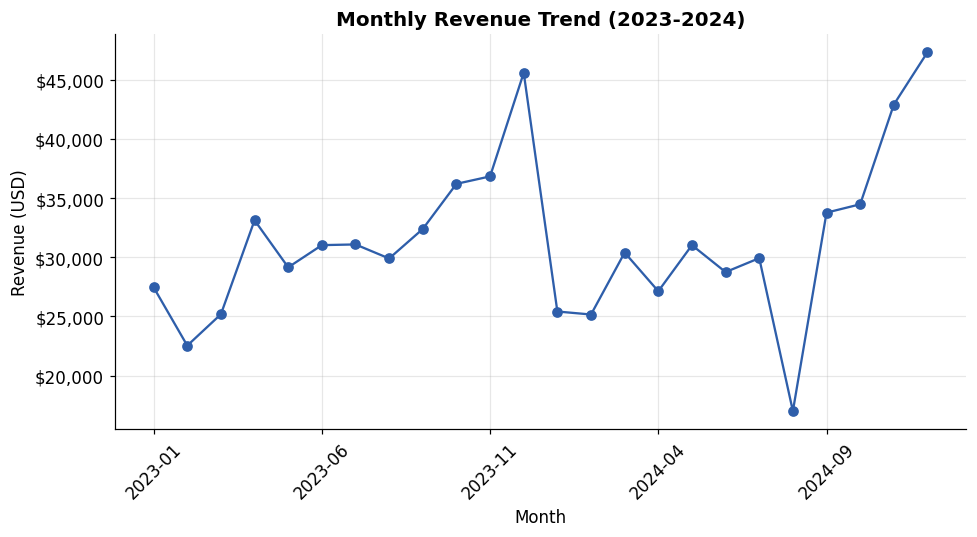

In [7]:
monthly_revenue = sales.groupby("YearMonth")["TotalPrice"].sum()

fig, ax = plt.subplots()
monthly_revenue.plot(kind="line", marker="o", color=COLOR, ax=ax)
ax.set_title("Monthly Revenue Trend (2023-2024)", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

pct_change = monthly_revenue.pct_change().mean()
print(f"Average month-over-month revenue growth: {pct_change:.1%}")
print(f"Peak month: {monthly_revenue.idxmax()} (${monthly_revenue.max():,.0f})")


**Insight:** Revenue peaks around November, consistent with holiday
shopping demand — this seasonality should inform inventory and marketing
spend timing.

### 4.2 Top-Selling Products & Categories

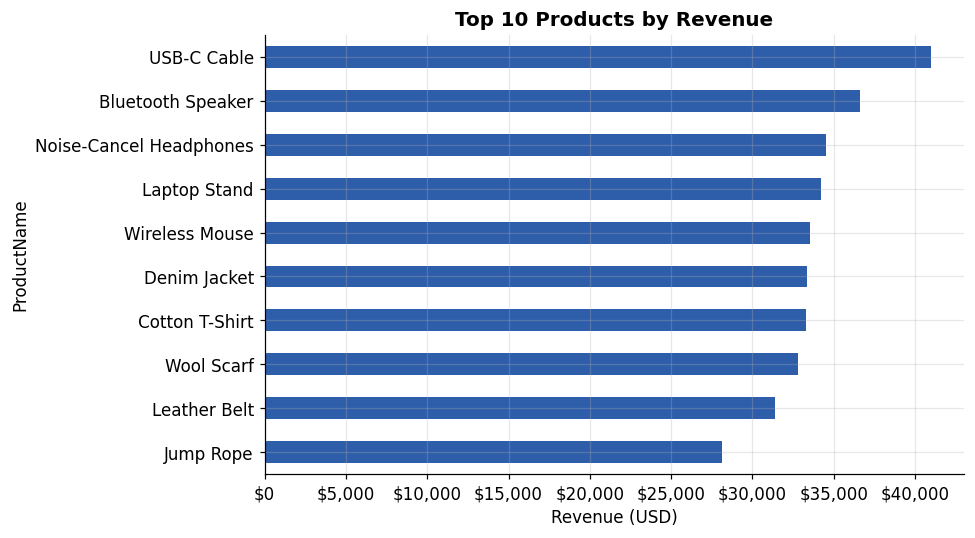

In [8]:
top_products = (sales.groupby("ProductName")["TotalPrice"]
                 .sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots()
top_products.sort_values().plot(kind="barh", color=COLOR, ax=ax)
ax.set_title("Top 10 Products by Revenue", fontsize=13, fontweight="bold")
ax.set_xlabel("Revenue (USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()


ProductCategory
Electronics        $179,817
Apparel            $156,045
Sports             $112,634
Home & Kitchen     $101,831
Toys & Games        $94,178
Beauty              $68,366
Office Supplies     $41,081
Name: TotalPrice, dtype: str


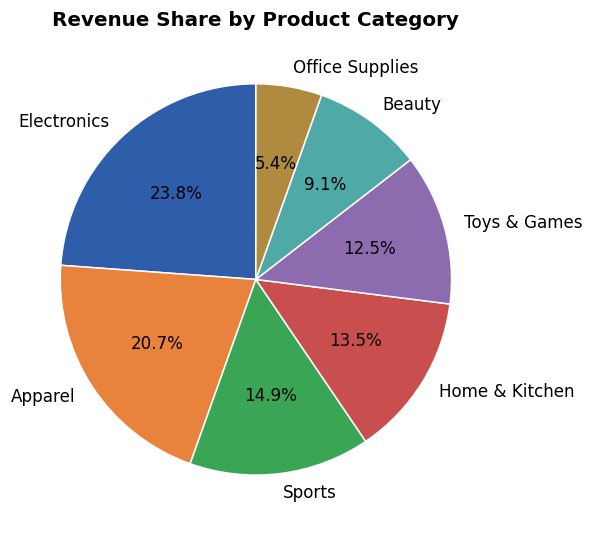

In [9]:
category_revenue = (sales.groupby("ProductCategory")["TotalPrice"]
                     .sum().sort_values(ascending=False))

fig, ax = plt.subplots()
ax.pie(category_revenue, labels=category_revenue.index, autopct="%1.1f%%",
       colors=PALETTE, startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 1})
ax.set_title("Revenue Share by Product Category", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(category_revenue.apply(lambda x: f"${x:,.0f}"))


### 4.3 Sales by Country (Customer Demographics)

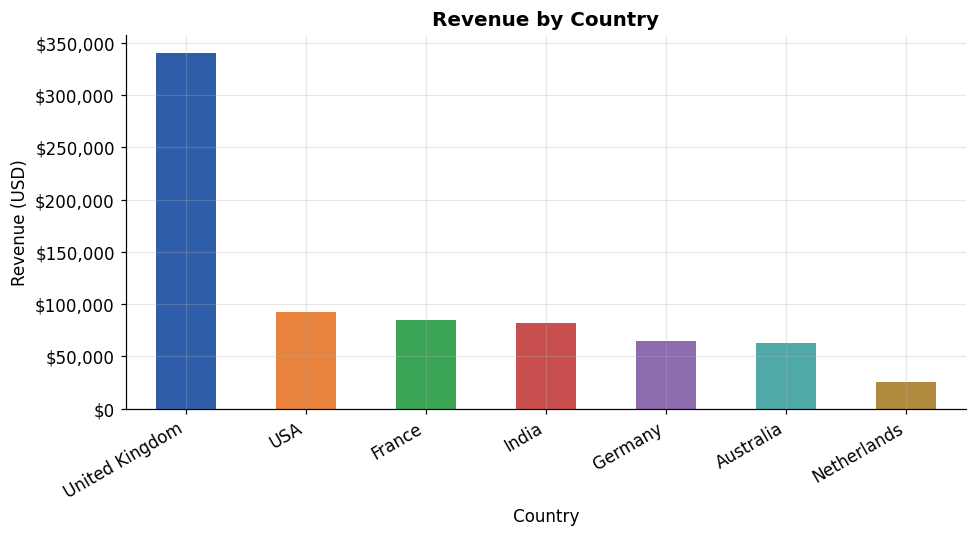

In [10]:
country_revenue = (sales.groupby("Country")["TotalPrice"]
                    .sum().sort_values(ascending=False))

fig, ax = plt.subplots()
country_revenue.plot(kind="bar", color=PALETTE, ax=ax)
ax.set_title("Revenue by Country", fontsize=13, fontweight="bold")
ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


**Insight:** Revenue is concentrated in a handful of core markets. This
points to where localized marketing or fulfillment investment would have
the highest return, while smaller markets may need a different growth
strategy (e.g. partnerships instead of paid ads).

### 4.4 Order Value Distribution

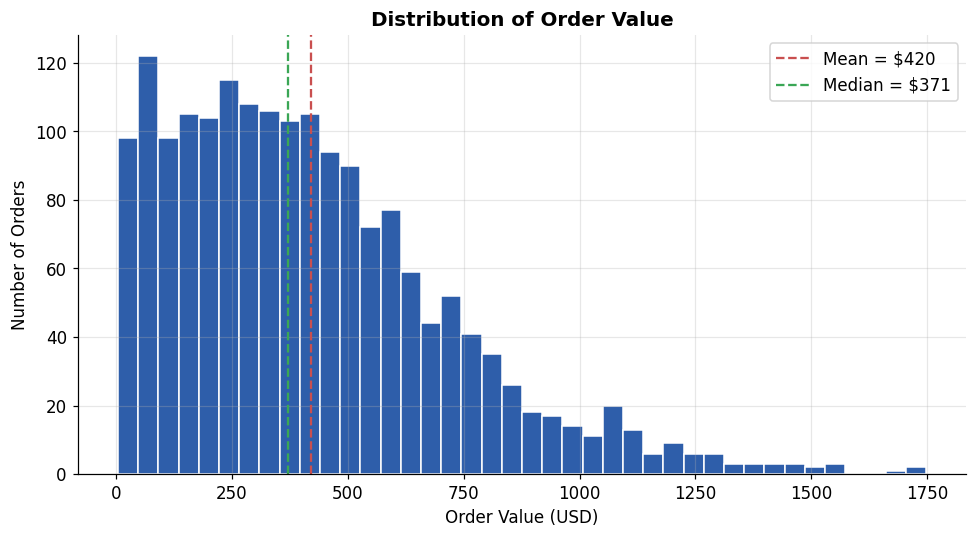

In [11]:
invoice_totals = sales.groupby("InvoiceNo")["TotalPrice"].sum()

fig, ax = plt.subplots()
ax.hist(invoice_totals, bins=40, color=COLOR, edgecolor="white")
ax.axvline(invoice_totals.mean(), color="#C94F4F", linestyle="--",
           label=f"Mean = ${invoice_totals.mean():,.0f}")
ax.axvline(invoice_totals.median(), color="#3AA655", linestyle="--",
           label=f"Median = ${invoice_totals.median():,.0f}")
ax.set_title("Distribution of Order Value", fontsize=13, fontweight="bold")
ax.set_xlabel("Order Value (USD)")
ax.set_ylabel("Number of Orders")
ax.legend()
plt.tight_layout()
plt.show()


**Insight:** The right-skewed distribution (mean > median) shows a
small number of large orders pull the average up — typical of retail data,
and a reason to look at median order value alongside averages when setting
KPIs.

## 5. Customer Segmentation: RFM Analysis + K-Means Clustering

To understand *who* is buying — not just what's selling — we build an
**RFM** profile for every customer:

- **Recency (R):** days since their most recent purchase (lower = more engaged)
- **Frequency (F):** number of distinct orders placed
- **Monetary (M):** total amount spent

We then use **K-Means clustering** to automatically group customers into
segments based on these three dimensions, rather than relying on arbitrary
manual cutoffs.

In [12]:
# Reference date = one day after the last transaction in the dataset
snapshot_date = sales_customer_known["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = sales_customer_known.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
).reset_index()

print(f"RFM table built for {len(rfm)} customers")
rfm.describe().round(1)


RFM table built for 349 customers


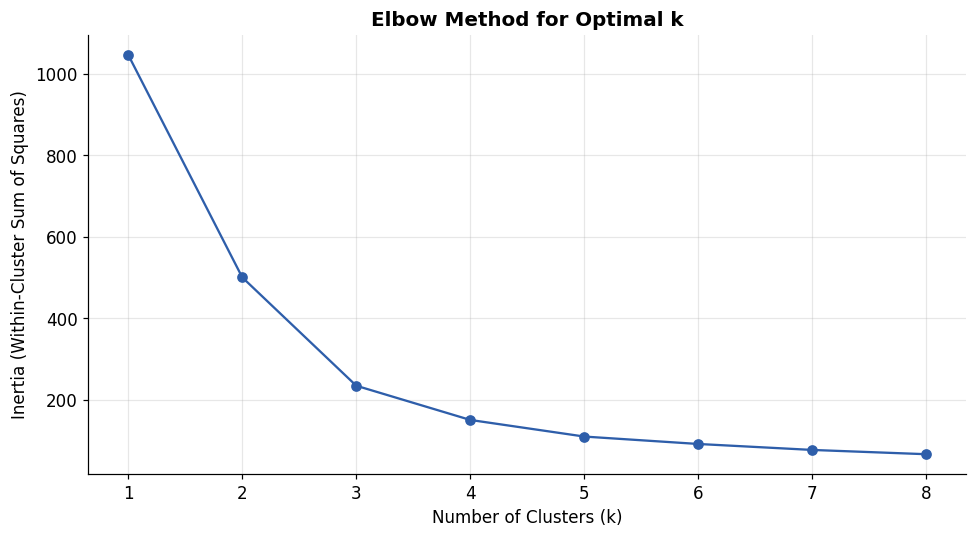

In [13]:
# Scale features before clustering — K-Means is distance-based, so
# Monetary (which is on a much larger numeric scale than Recency/Frequency)
# would otherwise dominate the distance calculation
features = rfm[["Recency", "Frequency", "Monetary"]]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Use the Elbow Method to choose a sensible number of clusters (k)
inertias = []
k_range = range(1, 9)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(scaled_features)
    inertias.append(km.inertia_)

fig, ax = plt.subplots()
ax.plot(list(k_range), inertias, marker="o", color=COLOR)
ax.set_title("Elbow Method for Optimal k", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.tight_layout()
plt.show()


**Choosing k:** The rate of improvement clearly slows after **k = 4**,
so we proceed with 4 clusters — a good balance between simplicity
(easy for marketing teams to act on) and capturing meaningful differences
between customer groups.

In [14]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(scaled_features)

# Profile each cluster by its average RFM values and size
cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    AvgRecency=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean"),
    AvgMonetary=("Monetary", "mean"),
).round(1).sort_values("AvgMonetary", ascending=False)

cluster_profile


In [15]:
# Give each data-driven cluster a business-friendly label based on its
# RFM profile (highest spend + most frequent + most recent = best customers)
label_order = cluster_profile.sort_values(
    ["AvgMonetary", "AvgFrequency"], ascending=False
).index.tolist()
labels = ["Champions", "Loyal Customers", "At-Risk", "Low-Value / One-Time"]
cluster_label_map = dict(zip(label_order, labels[:len(label_order)]))
rfm["Segment"] = rfm["Cluster"].map(cluster_label_map)

segment_summary = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    AvgRecencyDays=("Recency", "mean"),
    AvgOrders=("Frequency", "mean"),
    AvgSpend=("Monetary", "mean"),
    TotalRevenue=("Monetary", "sum"),
).round(1).sort_values("TotalRevenue", ascending=False)

segment_summary


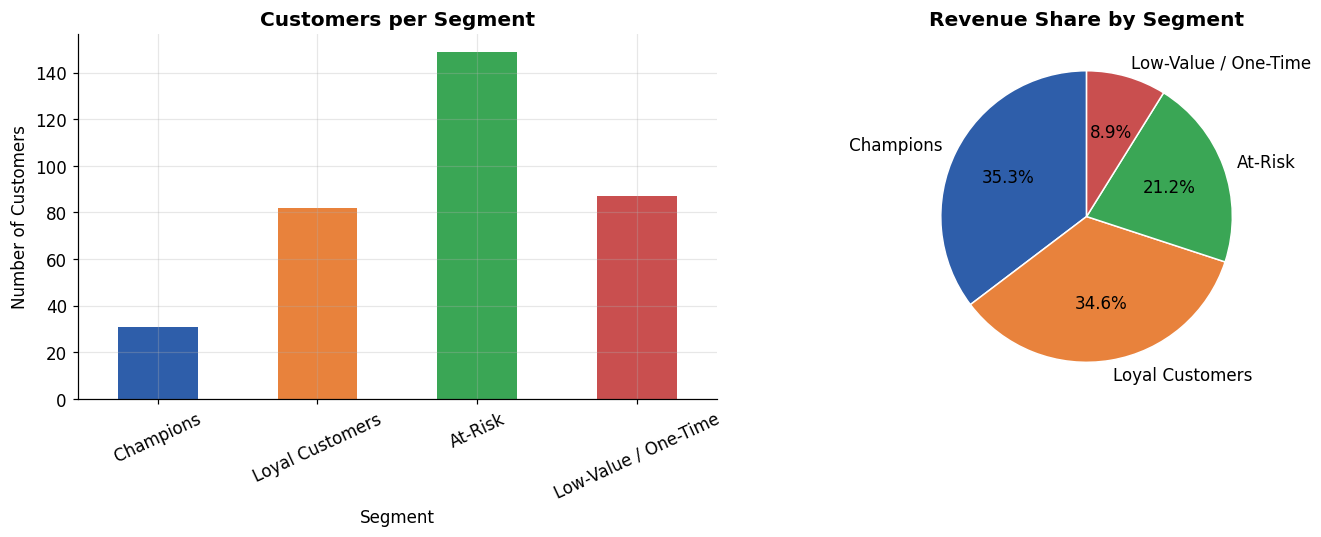

In [16]:
# Visualize segment sizes and their share of total revenue side-by-side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

segment_summary["Customers"].plot(
    kind="bar", ax=axes[0], color=PALETTE)
axes[0].set_title("Customers per Segment", fontweight="bold")
axes[0].set_ylabel("Number of Customers")
axes[0].tick_params(axis="x", rotation=25)

axes[1].pie(segment_summary["TotalRevenue"], labels=segment_summary.index,
            autopct="%1.1f%%", colors=PALETTE, startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1})
axes[1].set_title("Revenue Share by Segment", fontweight="bold")

plt.tight_layout()
plt.show()


**Insight:** Consistent with the Pareto principle, a small "Champions"
segment contributes a disproportionate share of total revenue. This is the
group to prioritize for loyalty programs and early access to new products,
while the "At-Risk" segment (high past value, but longer time since last
purchase) is the best target for win-back email campaigns.

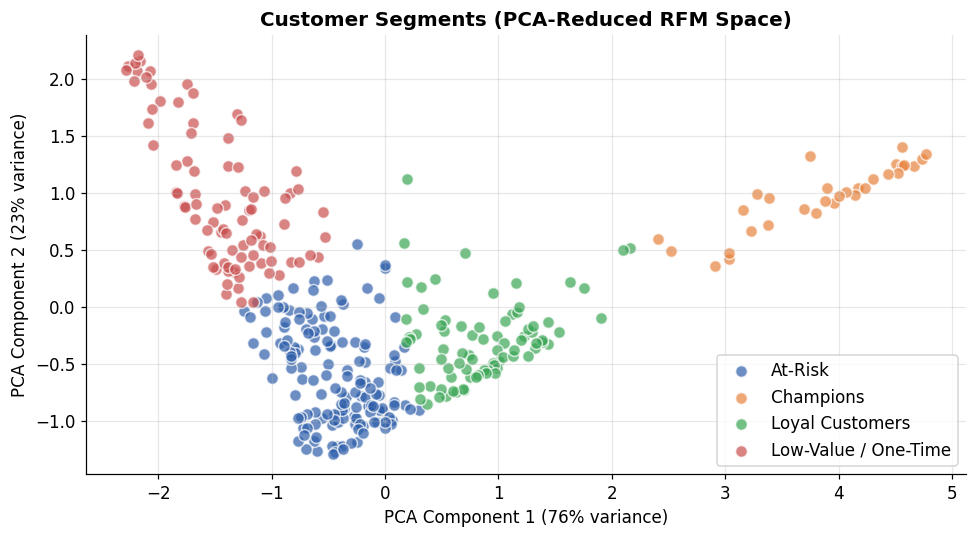

In [17]:
# Visualize the clusters in 2D using PCA (reduces 3 RFM dimensions to 2
# for plotting) so we can see how well-separated the segments are
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(scaled_features)
rfm["PCA1"], rfm["PCA2"] = pca_coords[:, 0], pca_coords[:, 1]

fig, ax = plt.subplots()
for i, seg in enumerate(rfm["Segment"].unique()):
    subset = rfm[rfm["Segment"] == seg]
    ax.scatter(subset["PCA1"], subset["PCA2"], label=seg,
               color=PALETTE[i % len(PALETTE)], alpha=0.7, edgecolor="white", s=60)

ax.set_title("Customer Segments (PCA-Reduced RFM Space)", fontsize=13, fontweight="bold")
ax.set_xlabel(f"PCA Component 1 ({pca.explained_variance_ratio_[0]:.0%} variance)")
ax.set_ylabel(f"PCA Component 2 ({pca.explained_variance_ratio_[1]:.0%} variance)")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Conclusion & Business Recommendations

### Key Findings
1. **Seasonality:** Revenue rises sharply toward Q4 (holiday shopping) —
   inventory and marketing budget should be planned to match this cycle
   rather than allocated evenly across the year.
2. **Product concentration:** A small number of products/categories account
   for a disproportionate share of revenue, meaning stockouts on these
   items are more costly than on the long tail.
3. **Customer concentration:** RFM + K-Means segmentation shows the classic
   80/20 pattern — the *Champions* segment is small but drives the largest
   share of revenue, while a large *Low-Value/One-Time* segment offers
   growth potential if converted to repeat buyers.
4. **Order value is right-skewed:** a handful of large orders inflate the
   average order value; median order value is a more stable KPI to track
   month over month.

### Recommendations
| Segment | Recommended Action |
|---|---|
| Champions | VIP loyalty perks, early product access, referral incentives |
| Loyal Customers | Cross-sell/upsell campaigns, subscription or bundle offers |
| At-Risk | Win-back email/discount campaigns before they churn completely |
| Low-Value / One-Time | Onboarding nurture sequence to drive a second purchase |

### Next Steps
- Extend this analysis with **cohort retention curves** to track how
  each acquisition month's customers behave over time.
- Layer in **product-level profit margins** (not just revenue) to prioritize
  promotions on high-margin items.
- Feed the RFM segment labels into the marketing team's CRM/email platform
  for automated, segment-specific campaigns.
- Re-run this exact pipeline on a live data feed (e.g. monthly) to track
  how segment sizes shift over time.

---
*This notebook is structured to run unchanged against the real UCI
"Online Retail" dataset (or any similarly-shaped transactional dataset) —
simply replace `retail_sales_data.csv` with the target file, keeping the
same column names.*
